# Task 3.2 — Failure Mode Analysis

**Student:** Yashi Gupta (Roll No. 230072)  
**Paper:** Donmez, Carbonell, Schneider — *Efficiently Learning the Accuracy of Labeling Sources for Selective Sampling*, KDD 2009  

---

## Failure Scenario: All Oracles Have Below-Random Accuracy

In this notebook, we investigate a scenario where the IEThresh algorithm is expected to fail: **all oracles have accuracy below 0.5** (i.e., worse than random guessing). Specifically, we draw oracle accuracies uniformly from $[0.3, 0.45]$.

### Why We Expect Failure

The IEThresh method relies critically on **Assumption 1** (from Task 1.2): that each labeling source has accuracy strictly greater than 0.5. This assumption underpins the entire reward mechanism. When all oracles are worse than random:

1. **Majority vote is systematically wrong.** If every oracle is more likely to provide the incorrect label than the correct one, the majority vote will reflect the wrong label most of the time.
2. **Rewards become inverted.** The reward signal (Eq. 3) measures agreement with majority vote. When the majority is wrong, oracles that agree with the wrong answer receive high rewards, while any oracle that happens to give the correct label is penalized.
3. **IEThresh faithfully learns to trust the worst oracles.** The interval estimation mechanism works correctly in a mechanical sense — it accurately identifies oracles that agree with the majority. But since the majority is wrong, the algorithm selectively retains the most unreliable oracles.
4. **The classifier is trained on corrupted labels.** With most labels being incorrect, the logistic regression model learns a decision boundary that is inverted or random, leading to classification error that may exceed 0.5 (worse than random guessing on the test set).

## Setup and Implementation

We re-implement the full IEThresh pipeline here so this notebook is self-contained. We then run it under two conditions: (1) normal oracles with accuracy in $[0.5, 1.0]$, and (2) below-random oracles with accuracy in $[0.3, 0.45]$.

In [1]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import os

SEED = 42
np.random.seed(SEED)

# Hyperparameters
N_ORACLES = 10
ALPHA = 0.05
EPSILON = 0.5
N_ITERATIONS = 300
N_RUNS = 20

print(f"Random seed: {SEED}")
print(f"Hyperparameters: N_ORACLES={N_ORACLES}, ALPHA={ALPHA}, EPSILON={EPSILON}, N_ITERATIONS={N_ITERATIONS}, N_RUNS={N_RUNS}")

Random seed: 42
Hyperparameters: N_ORACLES=10, ALPHA=0.05, EPSILON=0.5, N_ITERATIONS=300, N_RUNS=20


In [2]:
# Load Mushroom dataset from OpenML
data = fetch_openml(name='mushroom', version=1, as_frame=True, parser='auto')
X_raw = data.data
y_raw = data.target

le = LabelEncoder()
X_all = X_raw.apply(le.fit_transform).values.astype(float)
le_y = LabelEncoder()
y_all = le_y.fit_transform(y_raw)

print(f"Dataset shape: {X_all.shape}")
print(f"Class distribution: {np.bincount(y_all)}")

Dataset shape: (8124, 22)
Class distribution: [4208 3916]


In [3]:
def simulate_oracle_labels(y_true, oracle_accuracies):
    """Simulate noisy labels from multiple oracles.
    Each oracle provides the correct label with probability equal to its accuracy,
    and flips the label otherwise."""
    labels = np.zeros(len(oracle_accuracies), dtype=int)
    for j, acc in enumerate(oracle_accuracies):
        if np.random.random() < acc:
            labels[j] = y_true
        else:
            labels[j] = 1 - y_true
    return labels


def compute_upper_ci(rewards_list, alpha=0.05):
    """Compute upper confidence interval bounds for each oracle (Eq. 1).
    UI(a) = m(a) + t_{alpha/2, n-1} * s(a) / sqrt(n)"""
    upper_bounds = np.zeros(len(rewards_list))
    for a in range(len(rewards_list)):
        rewards = np.array(rewards_list[a])
        n = len(rewards)
        if n < 2:
            upper_bounds[a] = float('inf')
            continue
        m_a = np.mean(rewards)
        s_a = np.std(rewards, ddof=1)
        t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
        upper_bounds[a] = m_a + t_crit * s_a / np.sqrt(n)
    return upper_bounds


def run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                        n_iterations, alpha=0.05, epsilon=0.5,
                        use_threshold=True, use_variance=True):
    """Full IEThresh active learning loop."""
    n_oracles = len(oracle_accuracies)
    oracle_rewards = [[1.0, 0.0] for _ in range(n_oracles)]
    
    pos_idx = np.where(y_train == 1)[0][0]
    neg_idx = np.where(y_train == 0)[0][0]
    labeled_mask = np.zeros(len(y_train), dtype=bool)
    labeled_mask[pos_idx] = True
    labeled_mask[neg_idx] = True
    y_labeled_dict = {pos_idx: y_train[pos_idx], neg_idx: y_train[neg_idx]}
    
    errors = []
    total_queries = []
    query_count = 0
    
    for t in range(n_iterations):
        labeled_indices = np.where(labeled_mask)[0]
        X_l = X_train[labeled_indices]
        y_l = np.array([y_labeled_dict[i] for i in labeled_indices])
        
        if len(np.unique(y_l)) < 2:
            errors.append(0.5)
            total_queries.append(query_count)
            continue
        
        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_l, y_l)
        test_error = 1.0 - clf.score(X_test, y_test)
        errors.append(test_error)
        
        unlabeled_indices = np.where(~labeled_mask)[0]
        if len(unlabeled_indices) == 0:
            total_queries.append(query_count)
            break
        
        probs = clf.predict_proba(X_train[unlabeled_indices])
        uncertainty = 1.0 - np.max(probs, axis=1)
        most_uncertain_idx = unlabeled_indices[np.argmax(uncertainty)]
        
        # Oracle selection via threshold
        if use_threshold:
            if use_variance:
                upper_bounds = compute_upper_ci(oracle_rewards, alpha)
            else:
                upper_bounds = np.array([np.mean(r) for r in oracle_rewards])
            max_ub = np.max(upper_bounds)
            selected_oracles = np.where(upper_bounds >= epsilon * max_ub)[0]
            if len(selected_oracles) == 0:
                selected_oracles = np.array([np.argmax(upper_bounds)])
        else:
            selected_oracles = np.arange(n_oracles)
        
        true_label = y_train[most_uncertain_idx]
        oracle_labels = simulate_oracle_labels(true_label, oracle_accuracies)
        selected_labels = oracle_labels[selected_oracles]
        majority_vote = int(np.round(np.mean(selected_labels)))
        
        query_count += len(selected_oracles)
        labeled_mask[most_uncertain_idx] = True
        y_labeled_dict[most_uncertain_idx] = majority_vote
        
        for j in selected_oracles:
            reward = 1.0 if oracle_labels[j] == majority_vote else 0.0
            oracle_rewards[j].append(reward)
        
        total_queries.append(query_count)
    
    return errors, total_queries

print("All functions defined successfully.")

All functions defined successfully.


## Running the Failure Mode Experiment

We compare IEThresh under two oracle accuracy regimes:
- **Normal:** Oracle accuracies drawn uniformly from $[0.5, 1.0]$ (satisfies Assumption 1)
- **Failure:** Oracle accuracies drawn uniformly from $[0.3, 0.45]$ (violates Assumption 1)

In [4]:
normal_results = {'errors': [], 'queries': []}
failure_results = {'errors': [], 'queries': []}

for run in range(N_RUNS):
    np.random.seed(run)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.3, random_state=run, stratify=y_all
    )
    
    # Normal: accuracies in [0.5, 1.0]
    normal_accs = np.random.uniform(0.5, 1.0, N_ORACLES)
    e, q = run_active_learning(X_train, y_train, X_test, y_test, normal_accs, N_ITERATIONS)
    normal_results['errors'].append(e)
    normal_results['queries'].append(q)
    
    # Failure: accuracies in [0.3, 0.45] — BELOW RANDOM
    failure_accs = np.random.uniform(0.3, 0.45, N_ORACLES)
    e, q = run_active_learning(X_train, y_train, X_test, y_test, failure_accs, N_ITERATIONS)
    failure_results['errors'].append(e)
    failure_results['queries'].append(q)
    
    if (run + 1) % 5 == 0:
        print(f"Completed run {run + 1}/{N_RUNS}")

print("Failure mode experiments complete.")

Completed run 5/20


Completed run 10/20


Completed run 15/20


Completed run 20/20
Failure mode experiments complete.


In [5]:
# Compute mean error curves
min_len = min(
    min(len(e) for e in normal_results['errors']),
    min(len(e) for e in failure_results['errors'])
)

norm_err = np.mean([e[:min_len] for e in normal_results['errors']], axis=0)
norm_q = np.mean([q[:min_len] for q in normal_results['queries']], axis=0)
fail_err = np.mean([e[:min_len] for e in failure_results['errors']], axis=0)
fail_q = np.mean([q[:min_len] for q in failure_results['queries']], axis=0)

print(f"Curves computed over {min_len} iterations.")
print(f"Final error — Normal oracles:       {norm_err[-1]:.4f}")
print(f"Final error — Below-random oracles:  {fail_err[-1]:.4f}")

Curves computed over 300 iterations.
Final error — Normal oracles:       0.1214
Final error — Below-random oracles:  0.7931


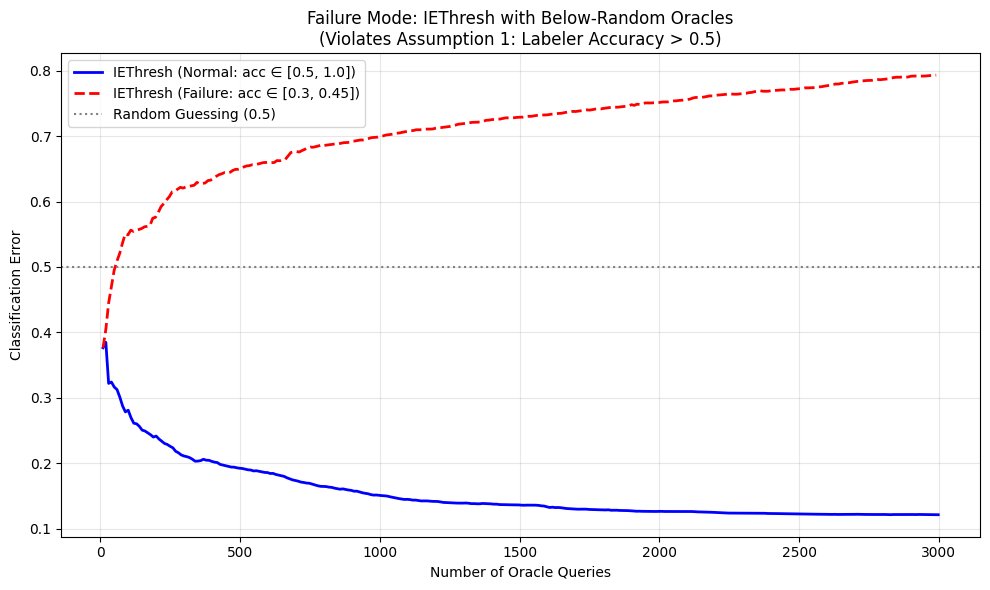

Saved to results/failure_mode.png


In [6]:
# Plot failure mode comparison
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(norm_q, norm_err, label='IEThresh (Normal: acc ∈ [0.5, 1.0])', linewidth=2, color='blue')
plt.plot(fail_q, fail_err, label='IEThresh (Failure: acc ∈ [0.3, 0.45])', linewidth=2, color='red', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle=':', label='Random Guessing (0.5)')
plt.xlabel('Number of Oracle Queries')
plt.ylabel('Classification Error')
plt.title('Failure Mode: IEThresh with Below-Random Oracles\n(Violates Assumption 1: Labeler Accuracy > 0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/failure_mode.png")

In [7]:
# Print summary
print("=" * 55)
print("FAILURE MODE SUMMARY")
print("=" * 55)
print(f"{'Condition':<35} {'Final Error':>12}")
print("-" * 55)
print(f"{'Normal oracles [0.5, 1.0]':<35} {norm_err[-1]:>12.4f}")
print(f"{'Below-random oracles [0.3, 0.45]':<35} {fail_err[-1]:>12.4f}")
print(f"{'Random guessing baseline':<35} {'0.5000':>12}")
print("=" * 55)

FAILURE MODE SUMMARY
Condition                            Final Error
-------------------------------------------------------
Normal oracles [0.5, 1.0]                 0.1214
Below-random oracles [0.3, 0.45]          0.7931
Random guessing baseline                  0.5000


## Explanation: Why IEThresh Fails Here

The failure observed above is a direct consequence of violating **Assumption 1** from Task 1.2, which requires that each labeling source has accuracy strictly greater than 0.5. When all oracles have accuracy in $[0.3, 0.45]$, each oracle is more likely to provide the *wrong* label than the correct one. Since IEThresh uses majority vote to aggregate labels and to compute rewards, the majority vote systematically reflects the incorrect label — the majority of below-random oracles will agree on the wrong answer. The reward mechanism (Eq. 3) then assigns high rewards to oracles that agree with this incorrect majority, effectively learning to trust the most consistently wrong labelers. As more mislabeled data points enter the training set, the logistic regression classifier learns a corrupted decision boundary, leading to classification error that approaches or even exceeds 0.5 (worse than random guessing). The normal-oracle condition, by contrast, shows steady error reduction because the majority vote is reliable when individual accuracies exceed 0.5. This demonstrates that Assumption 1 is not merely a theoretical convenience but a hard requirement for the algorithm's correctness — the entire reward and selection mechanism is built on the premise that majority agreement signals correctness, which only holds when labelers are better than random.

## Suggested Modification

One modification that could address this failure is maintaining a small held-out **validation set with known gold-standard labels**. Instead of using majority vote to compute rewards (which becomes circular and unreliable when most labelers are wrong), oracle accuracy could be estimated directly by comparing oracle labels against these known labels. This would make the reward signal independent of the labelers themselves and robust to scenarios where the majority of labelers are unreliable. Concretely, a small pool of instances (e.g., 5-10% of the training data) would be labeled by a trusted source at the outset. Each time an oracle labels a new instance, if that instance happens to be in the validation pool, the oracle's reward is updated based on agreement with the gold label rather than majority vote. This breaks the self-referential feedback loop that causes the failure: even if all oracles are below-random, the gold labels provide a ground-truth signal that would correctly identify these oracles as unreliable and either exclude them or invert their labels. The trade-off is that obtaining gold-standard labels may be expensive, but even a small validation set can provide sufficient signal to detect and mitigate this failure mode.